In [35]:
import pandas as pd
import numpy as np
import os


import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
''' \
goal: build a pkl object with the following structure:

{'graph': <networkx.classes.graph.Graph at 0x774566176360>,
 'coRT': <networkx.classes.graph.Graph at 0x7745c82b1e50>,
 'coURL': <networkx.classes.graph.Graph at 0x77455bb436e0>,
 'hashSeq': <networkx.classes.graph.Graph at 0x7745727f5100>,
 'fastRT': <networkx.classes.graph.Graph at 0x77456d5ccf20>,
 'tweetSim': <networkx.classes.graph.Graph at 0x77456057a900>,
 'labels': array([0., 0., 0., ..., 1., 1., 1.]),
 'splits': {0: {'train': array([False, False, False, ...,  True, False, False]),
   'val': array([ True,  True, False, ..., False,  True,  True]),
   'test': array([False, False,  True, ..., False, False, False])},
  1: {'train': array([False,  True,  True, ..., False,  True,  True]),
   'val': array([False, False, False, ...,  True, False, False]),
   'test': array([ True, False, False, ..., False, False, False])},
  2: {'train': array([False,  True,  True, ..., False,  True, False]),
   'val': array([False, False, False, ..., False, False,  True]),
   'test': array([ True, False, False, ...,  True, False, False])},
  3: {'train': array([False,  True,  True, ...,  True,  True,  True]),
   'val': array([ True, False, False, ..., False, False, False]),
   'test': array([False, False, False, ..., False, False, False])},
  4: {'train': array([False,  True, False, ...,  True,  True,  True]),
   'val': array([False, False,  True, ..., False, False, False]),
   'test': array([ True, False, False, ..., False, False, False])}}}


'''

hashtag_treshold = 0.9


## Data preparation

In [9]:
data_path = 'large_exps/1000 Agents/v2_hashtag_memory_1000.csv'
df = pd.read_csv(data_path)
df.head()


,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Recommendation,Commented On,Retweeted From,Retweet Reason,Strategy
0,1,SheilaNJ,0,🚨 It's time to prioritize our national securit...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,2,PaulDeCristofo4,0,🇺🇸 It's time to put America first! A strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,3,prinzeuschen,0,🇺🇸 It's time to put America first! We need str...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,4,FosteSherman,0,🇺🇸💪 It's time to prioritize our national secur...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,5,Crypto_Sanchez,0,🚨 It's time to put America first! 🇺🇸 Strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [10]:
## create a hashtags of tweets on the content
df['hashtags'] = df['Content'].astype(str).str.findall(r'#\w+')
df.head()

,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Recommendation,Commented On,Retweeted From,Retweet Reason,Strategy,hashtags
0,1,SheilaNJ,0,🚨 It's time to prioritize our national securit...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,[#BorderSecurity2024]
1,2,PaulDeCristofo4,0,🇺🇸 It's time to put America first! A strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #Trump2024]"
2,3,prinzeuschen,0,🇺🇸 It's time to put America first! We need str...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #Trump2024]"
3,4,FosteSherman,0,🇺🇸💪 It's time to prioritize our national secur...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #ConservativeValues]"
4,5,Crypto_Sanchez,0,🚨 It's time to put America first! 🇺🇸 Strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA]"


## Utils

In [49]:
users = df['Agent Name'].unique()


In [12]:
inorganic = set(df[df['Type'] != 'organic']['Agent Name'])

inorganic,len(inorganic)


({'1NationAND1God',
  'AMK292',
  'Aiker17939920',
  'AliceWa32036987',
  'AmateurMmo',
  'AmeriJeepRang2',
  'Animus58420344',
  'BahamaHerbie',
  'BandofPatriots',
  'BigballerShotc1',
  'CCP_USA_EU',
  'CLVPSN',
  'CMUDOH',
  'ClaimsStop',
  'ConnieNicarr',
  'CryptoNacky',
  'Crypto_Sanchez',
  'Daub14B',
  'Davidbiz0303',
  'Debbie22210',
  'DeejbechJ',
  'DogeCeratops',
  'Druid999S',
  'Eagleriver7J',
  'EdwardCarpente2',
  'FosteSherman',
  'HShirlain',
  'HudgensD',
  'IndyCarBoilers',
  'JGrenier_DZYN',
  'JayLochrie',
  'JoshSmith200733',
  'KatKat58726595',
  'LifeCo34475951',
  'LindyFulford',
  'MBOKSR_MAGA',
  'MarkJShuler',
  'MissDeadline',
  'Monstercoyliar',
  'MrsJ76884576',
  'PatriotRodSteel',
  'PaulDeCristofo4',
  'Penny20035',
  'QllectiveP',
  'RaveonRichmond',
  'SarahB1822',
  'ShakaQiu',
  'SheepDogSociety',
  'SheilaNJ',
  'SmileyBlanto',
  'Stardus95541064',
  'SuziGfromCT',
  'TanyaCarceller',
  'TheTrueChannel',
  'TjBluet',
  'Trumpster5280',
  'Uziel7

In [51]:
def plot_graph(graph, treshold):
    if len(users) == graph.number_of_nodes():
        mapping = {i: users[i] for i in range(len(users))}
    graph = nx.relabel_nodes(graph, mapping)

    print(graph.nodes)

    # remove isolated (single-town) nodes
    isolates = list(nx.isolates(graph))
    graph.remove_nodes_from(isolates)

    plt.figure(figsize=(12, 12))

    pos = nx.spring_layout(graph, seed=42, k=0.5)
    degrees = dict(graph.degree())

    node_color = [
        'red' if node in inorganic else 'blue'
        for node in graph.nodes
    ]

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=10,
        node_color=node_color,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        width=1.0,
        alpha=0.6
    )

    plt.axis('off')
    plt.title(f'Hashtag-based user similarity graph (threshold={treshold})')
    plt.show()

In [13]:
pickle_output = {}

## Hashtags

In [38]:
def hashtag_graph(df):
    # Create a bipartite graph''
    B = nx.Graph()
    # Add nodes for users and hashtags
    users = df['Agent Name'].unique()
    hashtags = set([hashtag for sublist in df['hashtags'] for hashtag in sublist])
    hashtags = list(hashtags)

    B.add_nodes_from(users, bipartite=0)
    B.add_nodes_from(hashtags, bipartite=1)
    # Add edges with weights based on the number of times a user used a hashtag
    for _, row in df.iterrows():
        user = row['Agent Name']
        for hashtag in row['hashtags']:
            if B.has_edge(user, hashtag):
                B[user][hashtag]['weight'] += 1
            else:
                B.add_edge(user, hashtag, weight=1)
    # Create a list of hashtag usage for each user
    user_hashtag_list = []
    for user in users:
        hashtags_used = []
        for hashtag in hashtags:
            if B.has_edge(user, hashtag):
                hashtags_used.append(hashtag)
        user_hashtag_list.append(' '.join(hashtags_used))
        
    # Compute TF-IDF vectors for users


        # consider just the upper diagonal of the similarity matrix, since it's symmetric and we don't want to consider the similarity of a user with itself


    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(user_hashtag_list)


    similarity_matrix = cosine_similarity(tfidf_matrix) 

    # Binarize similarity matrix based on threshold and zero out self-similarity
    similarity_matrix = (similarity_matrix > hashtag_treshold).astype(int)
    np.fill_diagonal(similarity_matrix, 0)

    return similarity_matrix


adj_matrix = hashtag_graph(df)




['SheilaNJ', 'PaulDeCristofo4', 'prinzeuschen', 'FosteSherman', 'Crypto_Sanchez', 'MissDeadline', 'girlzinger', 'RaveonRichmond', '1NationAND1God', 'HShirlain', 'barrett_sisters', 'fengshuilady5', 'amandaeweeks', 'eversollae', 'Uziel70562082', 'billyboblouise', 'TjBluet', 'SmileyBlanto', 'pokerchicca', 'suzyaz2', 'BahamaHerbie', 'TheTrueChannel', 'realMrEdCole', 'CMUDOH', 'ClaimsStop', 'IndyCarBoilers', 'chrisgoodbeats', 'SuziGfromCT', 'JayLochrie', 'aramis35426436', 'DogeCeratops', 'key2thehighway', 'fsalbiar', 'aGuyNamedRobit', 'AMK292', 'SarahB1822', 'MBOKSR_MAGA', 'hilltop3407', 'enriksommer', 'bornbornready', 'CLVPSN', 'JoshSmith200733', 'etrelas2orillas', 'atinydictator', 'maryderrickart', 'johns194901', 'Animus58420344', 'Davidbiz0303', 'Monstercoyliar', 'AmateurMmo', 'annie_amountain', 'Penny20035', 'Eagleriver7J', 'sharone777', 'DeejbechJ', 'AmeriJeepRang2', 'MrsJ76884576', 'SheepDogSociety', 'jack_saatjian', 'PatriotRodSteel', 'carol51378156', 'MarkJShuler', 'lchacone', 'gato

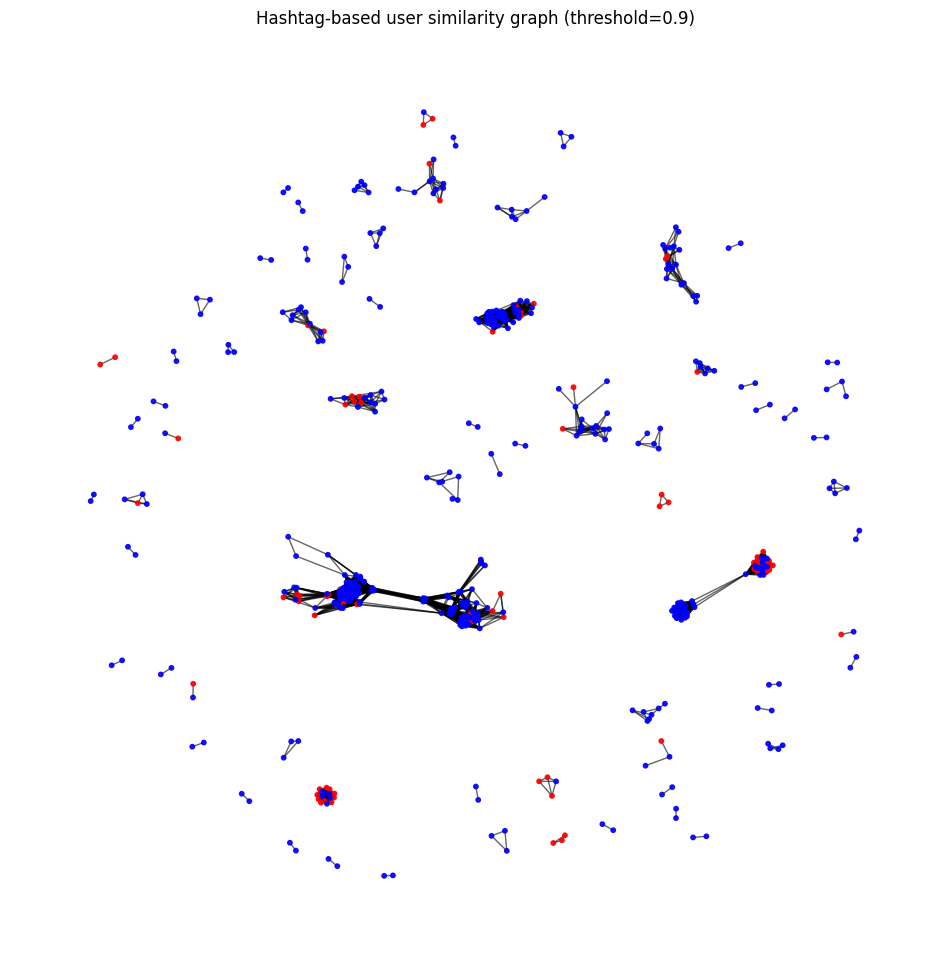

In [52]:
# create networkx graph from adj_matrix and label nodes with users
hashtag_graph = nx.from_numpy_array(adj_matrix)


plot_graph(hashtag_graph,hashtag_treshold)

In [40]:
sum([color == 'red' for color in node_color]),len(node_color)

(92, 529)

## Retweets 

In [48]:
df[ df['Retweeted From'].notna()].size

43092

In [ ]:
def hashtag_graph(df):
    # Create a bipartite graph''
    B = nx.Graph()
    # Add nodes for users and hashtags
    users = df['Agent Name'].unique()
    retweetd_tweets = set(df['Retweeted from'].notna())
    retweetd_tweets = list(retweetd_tweets)

    B.add_nodes_from(users, bipartite=0)
    B.add_nodes_from(retweetd_tweets, bipartite=1)
    # Add edges with weights based on the number of times a user used a hashtag
    for _, row in df.iterrows():
        user = row['Agent Name']
        for hashtag in row['hashtags']:
            if B.has_edge(user, hashtag):
                B[user][hashtag]['weight'] += 1
            else:
                B.add_edge(user, hashtag, weight=1)
    # Create a list of hashtag usage for each user
    user_hashtag_list = []
    for user in users:
        hashtags_used = []
        for hashtag in hashtags:
            if B.has_edge(user, hashtag):
                hashtags_used.append(hashtag)
        user_hashtag_list.append(' '.join(hashtags_used))
        
    # Compute TF-IDF vectors for users


        # consider just the upper diagonal of the similarity matrix, since it's symmetric and we don't want to consider the similarity of a user with itself


    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(user_hashtag_list)


    similarity_matrix = cosine_similarity(tfidf_matrix) 

    # Binarize similarity matrix based on threshold and zero out self-similarity
    similarity_matrix = (similarity_matrix > hashtag_treshold).astype(int)
    np.fill_diagonal(similarity_matrix, 0)

    return similarity_matrix
